# Validation: Tomek Links + ROS Hybrid on BC5CDR

BC5CDR has the most extreme imbalance (~67% `No_Relation`), so it's the sharpest test case for Tomek Links.

**Pipeline:**
1. Load BC5CDR train split (sentence-level pairs)
2. Apply entity markers (so embeddings reflect what the model sees)
3. Embed each marked sentence with `sentence-transformers/all-MiniLM-L6-v2`
4. Find Tomek Links (mutual nearest neighbors with opposite labels)
5. Remove the **majority-class** member of each link
6. Apply ROS to upsample minorities
7. Compare distributions at all three stages

If this looks promising, we'll generalize it to the rest of the pipeline.

In [5]:
! pip install "transformers>=4.36,<4.45"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 72.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.4 MB/s  0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.4
    Uninstalling tokenizers-0.21.4:
      Successfully uninstalled tokenizers-0.21.4
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━ 0/2 [tokenizers]
    Found existing installation: transformers 5.7.0 0/2 [tokenizers]
    Uninstalling transformers-5.7.0:━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-5.7.0;5;237m╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers]0m 1/2 [transformers]


In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from medre_bench.datasets.base import apply_entity_markers
from medre_bench.datasets.preprocessing import random_oversample
from medre_bench.registry import DATASET_REGISTRY
import medre_bench.datasets  # trigger registration

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

## 1. Load BC5CDR train and prepare marked sentences

In [2]:
ds_cls = DATASET_REGISTRY.get("bc5cdr")
ds = ds_cls()
examples = ds.load_split("train")
print(f"Loaded {len(examples):,} pair-level samples from BC5CDR train")

labels = np.array([ex.label_id for ex in examples])
label_names = ds.label_names()
print(f"Labels: {label_names}")
print(f"Distribution: {Counter(ex.label for ex in examples)}")

Loaded 22,396 pair-level samples from BC5CDR train
Labels: ['No_Relation', 'CID']
Distribution: Counter({'No_Relation': 20494, 'CID': 1902})


In [3]:
# Build the marked text — the actual input the model sees
marked_texts = []
for ex in examples:
    has_entities = (ex.entity1_start != ex.entity1_end) or (ex.entity2_start != ex.entity2_end)
    if has_entities:
        text = apply_entity_markers(
            text=ex.text,
            e1_start=ex.entity1_start,
            e1_end=ex.entity1_end,
            e1_type=ex.entity1_type,
            e2_start=ex.entity2_start,
            e2_end=ex.entity2_end,
            e2_type=ex.entity2_type,
            strategy="typed_entity_marker_punct",
        )
    else:
        text = ex.text
    marked_texts.append(text)

print(f"Sample marked text:\n{marked_texts[0][:500]}")

Sample marked text:
@ E1-chemical @ Naloxone @ /E1-chemical @  reverses the antihypertensive effect of # E2-chemical # clonidine # /E2-chemical # .


## 2. Embed sentences

Using `sentence-transformers/all-MiniLM-L6-v2` — 22M params, 384-dim embeddings, fast on CPU. If not installed, run: `pip install sentence-transformers`.

In [4]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
embeddings = model.encode(
    marked_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,  # cosine sim via dot product
)
print(f"Embeddings shape: {embeddings.shape}")

Using device: mps


Batches:   0%|          | 0/175 [00:00<?, ?it/s]

Embeddings shape: (22396, 384)


## 3. Find Tomek Links and remove majority-class samples

Implementation from scratch (no `imbalanced-learn` dep):
- Find nearest neighbor of each sample
- Pair (i, j) is a Tomek link iff `nn(i) == j AND nn(j) == i AND label(i) != label(j)`
- Remove the majority-class member of each link

In [5]:
from sklearn.neighbors import NearestNeighbors

# k=2 because k=1 always returns the point itself
nn = NearestNeighbors(n_neighbors=2, metric="cosine", n_jobs=-1)
nn.fit(embeddings)
_, neighbor_indices = nn.kneighbors(embeddings)
nearest = neighbor_indices[:, 1]  # second-nearest = first non-self

# A Tomek link: mutual nearest neighbors with different labels
tomek_mask = np.zeros(len(examples), dtype=bool)
majority_class = Counter(labels).most_common(1)[0][0]  # No_Relation = id 0 here

for i, j in enumerate(nearest):
    if nearest[j] == i and labels[i] != labels[j]:
        # Remove the majority-class member
        if labels[i] == majority_class:
            tomek_mask[i] = True
        else:
            tomek_mask[j] = True

n_links = tomek_mask.sum()
print(f"Found {n_links:,} Tomek links to remove ({n_links/len(examples)*100:.1f}% of train)")
print(f"Class breakdown of removed samples: {Counter(labels[tomek_mask])}")

Found 1,522 Tomek links to remove (6.8% of train)
Class breakdown of removed samples: Counter({0: 1522})


In [6]:
# Build the cleaned train set
keep_mask = ~tomek_mask
examples_after_tomek = [ex for ex, keep in zip(examples, keep_mask) if keep]

print(f"Before Tomek: {len(examples):,}")
print(f"After Tomek:  {len(examples_after_tomek):,}")
print(f"Removed:      {len(examples) - len(examples_after_tomek):,} ({(len(examples) - len(examples_after_tomek))/len(examples)*100:.1f}%)")

print("\nClass distribution:")
before_dist = Counter(ex.label for ex in examples)
after_dist = Counter(ex.label for ex in examples_after_tomek)
for label in sorted(before_dist.keys()):
    b = before_dist[label]
    a = after_dist[label]
    print(f"  {label:15s}  {b:7,d} -> {a:7,d}  (Δ {a-b:+,d}, {(a-b)/b*100:+.1f}%)")

Before Tomek: 22,396
After Tomek:  20,874
Removed:      1,522 (6.8%)

Class distribution:
  CID                1,902 ->   1,902  (Δ +0, +0.0%)
  No_Relation       20,494 ->  18,972  (Δ -1,522, -7.4%)


## 4. Apply ROS after Tomek

In [7]:
examples_after_ros_only = random_oversample(examples, seed=42)
examples_after_tomek_ros = random_oversample(examples_after_tomek, seed=42)

stages = {
    "Original": examples,
    "ROS only": examples_after_ros_only,
    "Tomek only": examples_after_tomek,
    "Tomek + ROS": examples_after_tomek_ros,
}

rows = []
for stage, exs in stages.items():
    counts = Counter(ex.label for ex in exs)
    rows.append({
        "Stage": stage,
        "Total": len(exs),
        "No_Relation": counts.get("No_Relation", 0),
        "CID": counts.get("CID", 0),
        "Pos %": f"{counts.get('CID', 0)/len(exs)*100:.1f}%",
        "Imbalance (neg:pos)": f"{counts.get('No_Relation', 0)/max(counts.get('CID', 1), 1):.2f}",
    })

pd.DataFrame(rows)

,Stage,Total,No_Relation,CID,Pos %,Imbalance (neg:pos)
0,Original,22396,20494,1902,8.5%,10.77
1,ROS only,40988,20494,20494,50.0%,1.00
2,Tomek only,20874,18972,1902,9.1%,9.97
3,Tomek + ROS,37944,18972,18972,50.0%,1.00


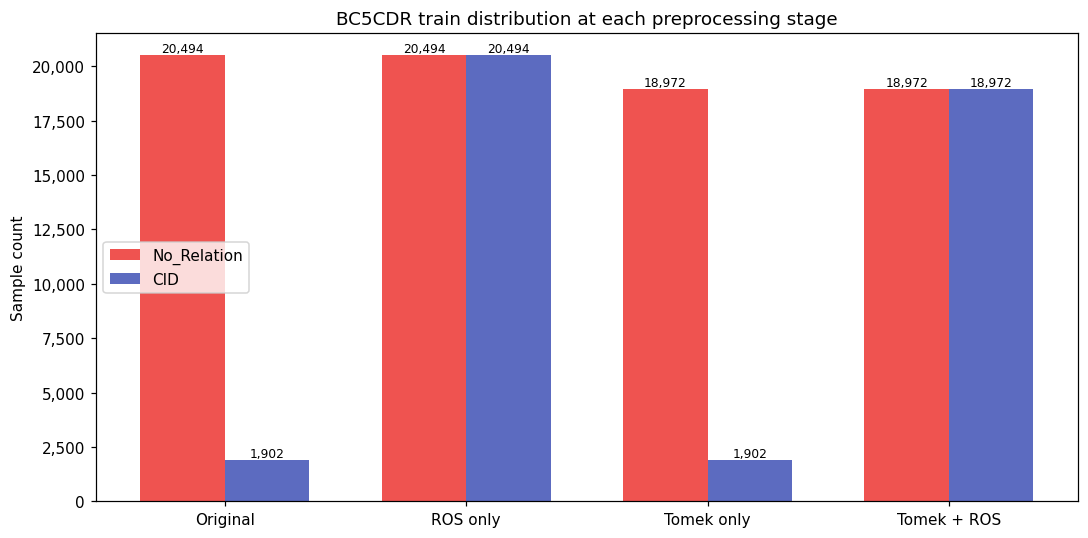

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
stages_list = list(stages.keys())
x = np.arange(len(stages_list))
w = 0.35

neg_counts = [Counter(ex.label for ex in stages[s]).get("No_Relation", 0) for s in stages_list]
pos_counts = [Counter(ex.label for ex in stages[s]).get("CID", 0) for s in stages_list]

ax.bar(x - w/2, neg_counts, w, label="No_Relation", color="#EF5350")
ax.bar(x + w/2, pos_counts, w, label="CID", color="#5C6BC0")

for i, (n, p) in enumerate(zip(neg_counts, pos_counts)):
    ax.text(i - w/2, n, f"{n:,}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, p, f"{p:,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(stages_list)
ax.set_ylabel("Sample count")
ax.set_title("BC5CDR train distribution at each preprocessing stage")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Inspect what Tomek removed

Sanity check: are the removed `No_Relation` samples actually borderline / ambiguous? Look at a few of them along with their nearest opposite-class neighbor.

In [9]:
removed_indices = np.where(tomek_mask)[0]
rng = np.random.default_rng(42)
sample_idx = rng.choice(removed_indices, size=min(5, len(removed_indices)), replace=False)

for k, i in enumerate(sample_idx, 1):
    j = nearest[i]
    print(f"--- Removed sample {k} ---")
    print(f"[REMOVED] Label: {examples[i].label} ({examples[i].entity1} <-> {examples[i].entity2})")
    print(f"  Sentence: {examples[i].text[:250]}{'...' if len(examples[i].text) > 250 else ''}")
    print(f"[NEAREST] Label: {examples[j].label} ({examples[j].entity1} <-> {examples[j].entity2})")
    print(f"  Sentence: {examples[j].text[:250]}{'...' if len(examples[j].text) > 250 else ''}")
    print()

--- Removed sample 1 ---
[REMOVED] Label: No_Relation (hypotension <-> prostaglandin E1)
  Sentence: Combined effects of prolonged prostaglandin E1 (PGE1)-induced hypotension and haemodilution on hepatic function were studied in 30 patients undergoing hip surgery.
[NEAREST] Label: CID (prostaglandin E1 <-> hypotension)
  Sentence: Combined effects of prolonged prostaglandin E1 (PGE1)-induced hypotension and haemodilution on hepatic function were studied in 30 patients undergoing hip surgery.

--- Removed sample 2 ---
[REMOVED] Label: No_Relation (cardiac hypertrophy <-> Isoproterenol)
  Sentence: Isoproterenol pretreatment for 15 days caused cardiac hypertrophy without affecting baseline blood pressure and heart rate.
[NEAREST] Label: CID (Isoproterenol <-> cardiac hypertrophy)
  Sentence: Isoproterenol pretreatment for 15 days caused cardiac hypertrophy without affecting baseline blood pressure and heart rate.

--- Removed sample 3 ---
[REMOVED] Label: No_Relation (LID <-> L-DOPA)
  S

## 6. Verdict

Read the metrics + samples above and decide:
- **Did Tomek remove a meaningful number of negatives?** If <1%, it's not worth the preprocessing overhead — fall back to ROS-only.
- **Are the removed sentences actually ambiguous?** Reading the inspection cell, do removed `No_Relation` examples look genuinely borderline (close in language to true `CID` cases)?
- **Final imbalance:** `Tomek + ROS` should produce a perfectly balanced train set with fewer total samples than `ROS only`, and presumably cleaner boundaries.

If results look good, we'll wire this into `preprocessing.py` and `trainer.py` behind a `dataset.cleaning_strategy` flag and run a full benchmark to confirm the F1/AUC improvement on the held-out test set.